In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings #used to avoid small errors
warnings.filterwarnings('ignore')
print("All libraries imported successfully")
print(f"pandas version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.version}")


All libraries imported successfully
pandas version:2.2.2
sqlite3 version:2.6.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


STEP 1:Load the CSV DATASET FROM DAY01

In [ ]:
df=pd.read_csv("student_performance.csv")
print(f"Dataset Loaded:{df.shape[0]} students,{df.shape[1]}")
#shape[0] is used to display the size of the row and shape[1] is used to display the size of the column
print(f"Columns:{df.columns.tolist()}")
#tolist is used to diaply the name of row or column
df.head(3)

Dataset Loaded:30 students,13
Columns:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


CREATING TABLE AND ACCESSING THE DATA USING SQLITE

In [ ]:
conn=sqlite3.connect('college.db') #creates the new database
cursor=conn.cursor() #sql execution tool ,every query goes through the cursor
df.to_sql(
    'students',#table name
    conn, #creating this table inside the college.db
    if_exists='replace',# if the table already exists that will be replace with the new table
    index=False#sometimes sql take row as column number ,so to avoid that this is used

)
cursor.execute("SELECT COUNT(*) FROM students") # used to return number of rows
count=cursor.fetchone()[0]
print(f"Database 'college.db' created successfully")
print(f"Table students has {count} rows")

Database 'college.db' created successfully
Table students has 30 rows


In [ ]:
cursor.execute("PRAGMA table_info(students)")  #PRAGMA is a special sqlite command (not a standard sql),table_info shows the structure of a table
columns_info=cursor.fetchall() #fetchall is used to retrieve all result rows
print("Table structure of 'students")
print(f"{'Column Name':<25}{'Data type':<12}") #<25 means left align in 25 characters
print("-"*38)
#for printing "-" 38 times
for col in columns_info:
  #col is a tuple:{id,name,type,notnull,default,pk}
  print(f"{col[1]:<25} {col[2]:<12}")
  #col[1] "column_name" ,col[2] datatype
  #:<25 means left align in 25 character


Table structure of 'students
Column Name              Data type   
--------------------------------------
student_id                INTEGER     
name                      TEXT        
age                       INTEGER     
gender                    TEXT        
department                TEXT        
semester                  INTEGER     
math_score                INTEGER     
science_score             INTEGER     
english_score             INTEGER     
programming_score         INTEGER     
attendance_percentage     INTEGER     
city                      TEXT        
admission_year            INTEGER     


The Standard SQL Query Pattern
SELECT column1,column2
FROM  table_name
WHERE condition
GROUP BY COLUMN
HAVING group_condition
ORDER BY column DESC
LIMIT 20;

In [ ]:
def run_query(sql,description=""):
  """
  Runs a SQL query and returns results as a Pandas DataFrame.
  Parameters:
  -----------
  sql:str - The SQL query string to execute
  description:str - A label to print above the results
  Returns:
  -------
  Pandas DataFrame contaning the query results
  """
  if description:
    print(f"\n{'='*55}")
    print(f"{description}")
    print(f"{'='*55}")
  result = pd.read_sql_query(sql,conn)
  #pd.read_sql_query() does two things
  #1. Executes the sql query against our databse(conn)
  #2. converts the results into a pandas Dataframe
  #this is the key function connnecting sql + pandas
  print(result.to_string(index=False))
  print(run_query)
  return result
print("Helper function 'run_query' defined successfully!")
print("usage: run_query(sql_string, description_label)")



Helper function 'run_query' defined successfully!
usage: run_query(sql_string, description_label)


1.find total number of students
2.display all column names and data types using pragma
3.show first 5 rows from the students table
4.display students with math mark>80
5.count number of male and female students

In [ ]:
cursor.execute("SELECT COUNT(*) FROM students") # used to return number of rows
count=cursor.fetchone()[0]
print(f"Total number of students:{count}")
cursor.execute(" ")

Total number of students:30


In [ ]:
#SQL QUERY BASIC SELECT
query1="""
    SELECT student_id,name,department,math_score,attendance_percentage
    FROM students
    LIMIT 10
    """
result1=run_query(query1,"Query 1: First 10 Students(SELECT+LIMIT)")



Query 1: First 10 Students(SELECT+LIMIT)
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98
<function run_query at 0x7f7d7d6c2c00>


In [ ]:
query2="""
    SELECT name,department,math_score
    FROM students
    ORDER BY math_score DESC
    LIMIT 5
    """
reult2=run_query(query2,"Query 2:Top 5 Math Scores(ORDER BY DESC+LIMIT)")


Query 2:Top 5 Math Scores(ORDER BY DESC+LIMIT)
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90
<function run_query at 0x7f7d7d6c2c00>


FILTER BY DEPARTMENT

In [ ]:
query3="""
SELECT name,math_score,science_score,programming_score,attendance_percentage
FROM students
WHERE department='Computer Science'
ORDER BY programming_score DESC
"""
result3=run_query(query3,"Query 3:Computer Science Students (WHERE filter)")
print(f"\nTotal students found:{len(result3)}")


Query 3:Computer Science Students (WHERE filter)
          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87
  Nisha Kapoor          79

In [ ]:
query4="""
SELECT name,department,attendance_percentage
FROM students
WHERE attendance_percentage>90
AND department !='Civil'
ORDER BY attendance_percentage DESC
"""
result4=run_query(query4,"Query 4:High Attendance (>90%) Excluding Civil Dept")


Query 4:High Attendance (>90%) Excluding Civil Dept
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91
<function run_query at 0x7f7d7d6c2c00>


Avergae score per department (GROUP BY +AVG)

In [ ]:
query5="""
    SELECT
       department,
       COUNT(*) AS student_count,
       ROUND(AVG(math_Score),2) AS avg_math_score,
       ROUND(AVG(science_score),2) AS avg_science_score,
       ROUND(AVG(programming_score),2) AS avg_programming_score,
       ROUND(AVG(attendance_percentage),2) AS avg_attendance_percentage
    FROM students
    GROUP BY department
    ORDER BY avg_math_score DESC
    """
result5=run_query(query5,"Query 5:Department wise Average Score (GROUP BY)")


Query 5:Department wise Average Score (GROUP BY)
      department  student_count  avg_math_score  avg_science_score  avg_programming_score  avg_attendance_percentage
Computer Science             13           85.62              84.46                  89.23                      90.69
      Mechanical              6           71.00              76.50                  49.33                      83.50
     Electronics              6           71.00              74.17                  61.50                      80.33
           Civil              5           63.40              66.60                  40.60                      74.60
<function run_query at 0x7f7d7d6c2c00>


In [ ]:
query6="""
   SELECT
     department,
     ROUND(AVG(math_Score),2) AS avg_math,
     COUNT(*) AS students
  FROM students
  GROUP BY department
  HAVING (AVG(math_score)>70)
  ORDER BY avg_math DESC
  """
result6=run_query(query6,"Query 6:Departments with Average Math Score>70 (HAVING)")


Query 6:Departments with Average Math Score>70 (HAVING)
      department  avg_math  students
Computer Science     85.62        13
      Mechanical     71.00         6
     Electronics     71.00         6
<function run_query at 0x7f7d7d6c2c00>


In [ ]:
query7="""
  SELECT
     gender,
     COUNT(*) AS num_students,
     ROUND(AVG(math_Score),2) AS avg_math_score,
     ROUND(AVG(programming_Score),2) AS avg_programming_score,
     ROUND(AVG(attendance_percentage),2) AS avg_attendance_percentage
FROM students
GROUP BY gender
"""
result7=run_query(query7,"Query 7:Gender wise Performance Analysis")


Query 7:Gender wise Performance Analysis
gender  num_students  avg_math_score  avg_programming_score  avg_attendance_percentage
Female            15           78.47                   70.2                      88.53
  Male            15           73.67                   65.0                      80.47
<function run_query at 0x7f7d7d6c2c00>


In [ ]:
query8="""
    SELECT
      name,
      department,
      math_score+science_score+english_score+programming_score as total_score
    FROM students
    ORDER BY total_score DESC
    LIMIT 10
    """
result8=run_query(query8,"Top 10 students based on the Total Score")


Top 10 students based on the Total Score
          name       department  total_score
    Ananya Das Computer Science          371
   Tanvi Mehta Computer Science          367
Akanksha Yadav Computer Science          365
    Arjun Nair Computer Science          356
   Divya Singh Computer Science          356
Swati Kulkarni Computer Science          354
     Amit Bose Computer Science          336
    Suresh Rao Computer Science          334
  Nisha Kapoor Computer Science          327
  Aarav Sharma Computer Science          326
<function run_query at 0x7f7d7d6c2c00>


In [ ]:
dept_data={
    'dept_code':['CS','IT','ME','CIVIL'],
    'dept_name':['Computer Science','Information Technology','Mechanical','Civil'],
    'hod_name': ['Dr.Sharma','Dr.Reddy','Dr.Patel','Dr.Kumar'],
    'established': [1985,1988,1972,1965],
    'intake':[60,60,60,60]
}
dept_df=pd.DataFrame(dept_data)
dept_df.to_sql('departments',conn,if_exists='replace',index=False)
print("Created 'departments' table:")
print(dept_df.to_string(index=False))
dept_map={
    'Computer Science':'CS',
    'Electronics':'EC',
    'Mechanical':'ME',
    'Civil':'CE'

}
df['dept_code']=df['department'].map(dept_map)
df.to_sql('students',conn,if_exists='replace',index=False)
print("\nUpdated students table with dept_code column")




Created 'departments' table:
dept_code              dept_name  hod_name  established  intake
       CS       Computer Science Dr.Sharma         1985      60
       IT Information Technology  Dr.Reddy         1988      60
       ME             Mechanical  Dr.Patel         1972      60
    CIVIL                  Civil  Dr.Kumar         1965      60

Updated students table with dept_code column


In [ ]:
query_join="""
  SELECT
     s.name,
     s.math_Score,
     d.dept_name,
     d.hod_name,
     d.established
  FROM students AS s
  INNER JOIN departments AS d
     ON s.dept_code=d.dept_code
  ORDER BY s.math_score DESC
  LIMIT 8
  """
result_join=run_query(query_join,"JOIN: Students with Department Details(INNER JOIN)")


JOIN: Students with Department Details(INNER JOIN)
          name  math_score        dept_name  hod_name  established
    Ananya Das          95 Computer Science Dr.Sharma         1985
   Tanvi Mehta          93 Computer Science Dr.Sharma         1985
    Arjun Nair          92 Computer Science Dr.Sharma         1985
Akanksha Yadav          91 Computer Science Dr.Sharma         1985
Swati Kulkarni          90 Computer Science Dr.Sharma         1985
   Divya Singh          88 Computer Science Dr.Sharma         1985
     Amit Bose          86 Computer Science Dr.Sharma         1985
  Aarav Sharma          85 Computer Science Dr.Sharma         1985
<function run_query at 0x7f7d7d6c2c00>


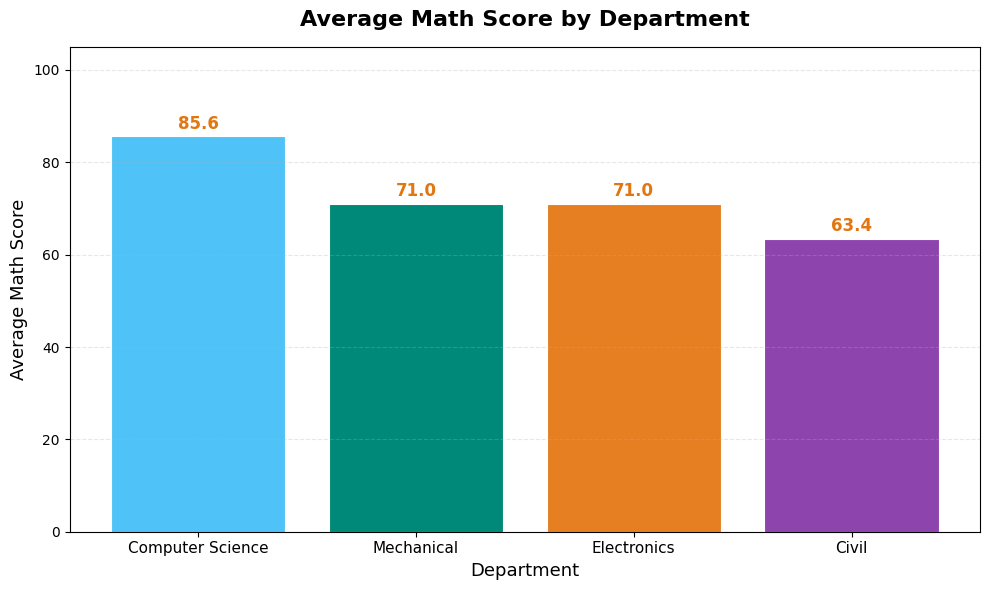

In [ ]:
chart1_sql="""
  SELECT department,ROUND(AVG(math_score),2) AS  avg_math
  FROM students
  GROUP BY department
  ORDER BY avg_math DESC
  """
chart1_data=pd.read_sql_query(chart1_sql,conn)
fig,ax=plt.subplots(figsize=(10,6))
bar_colors=['#4FC3F7','#008978','#E67E22','#8E44AD']
bars=ax.bar(
    chart1_data['department'],
    chart1_data['avg_math'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)
for bar in bars:
  height=bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height+0.8,
      f'{height:.1f}',
      ha='center',va='bottom',
      fontsize=12,fontweight='bold',
      color='#E27610'
  )
ax.set_title('Average Math Score by Department',fontsize=16,fontweight='bold',pad=15)
ax.set_xlabel('Department',fontsize=13)
ax.set_ylabel('Average Math Score',fontsize=13)
ax.set_ylim(0,105)
ax.tick_params(axis='x',labelsize=11)
ax.grid(axis='y',alpha=0.3,linestyle='--')
plt.tight_layout()
plt.show()

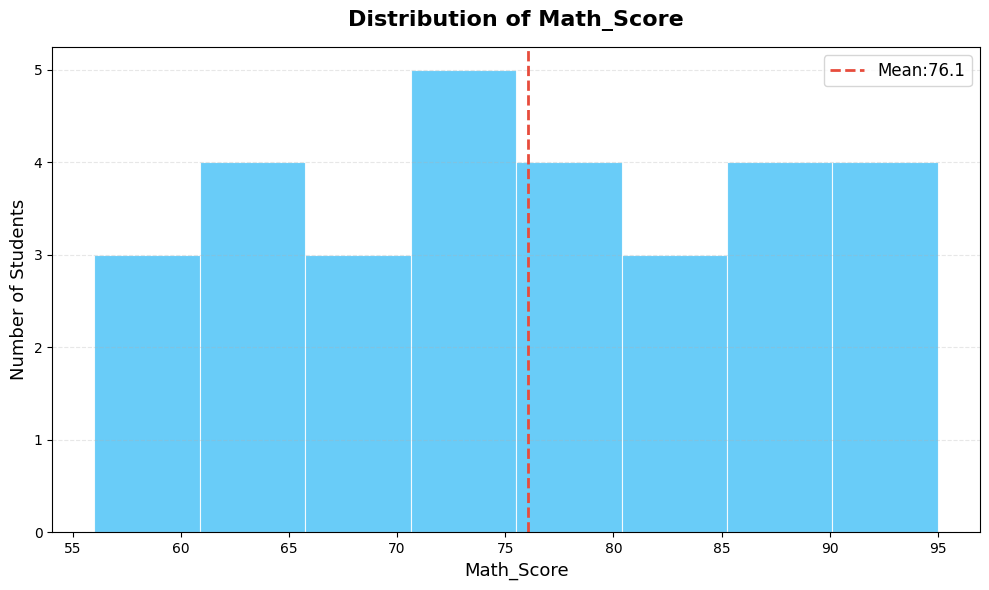

In [ ]:
math_score=df['math_score'].tolist()
fig,ax=plt.subplots(figsize=(10,6))
n,bins,patches=ax.hist(
    math_score,
    bins=8,
    color='#4FC3F7',
    edgecolor='white',
    linewidth=0.8,
    alpha=0.85
)
mean_score=sum(math_score)/len(math_score)
ax.axvline(
    x=mean_score,
    color='#E74C3C',
    linestyle='--',
    linewidth=2,
    label=f'Mean:{mean_score:.1f}'
)
ax.set_title('Distribution of Math_Score',fontsize=16,fontweight='bold',pad=15)
ax.set_xlabel('Math_Score',fontsize=13)
ax.set_ylabel('Number of Students',fontsize=13)
ax.legend(fontsize=12)
ax.grid(axis='y',alpha=0.3,linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
df=pd.DataFrame({
    'Category':np.random.choice(['A','B','C','D'],100),
    'Value':np.random.randint(10,100,100),
    'Score':np.random.randint(1,10,100)

})
df.head()

,Category,Value,Score
0,A,94,1
1,A,23,5
2,B,99,5
3,B,88,9
4,C,53,5


In [ ]:
import plotly.express as px

# Calculate category counts from the 'df' DataFrame
category_counts = df['Category'].value_counts().reset_index()
category_counts.columns=['Category','Count']

fig=px.bar(
    category_counts,
    x='Category',
    y='Count',
    color='Category',
    title='Interactive Category Distribution',
    text='Count'
)
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_title='Category',yaxis_title='Count')
fig.show()

SQL query to find average programming score for female students only

In [ ]:
ans1=pd.read_sql_query("""
SELECT AVG(programming_score) AS avg_prog_score
FROM students
WHERE gender='Female'
""",conn)
print(ans1)

   avg_prog_score
0            70.2


Write the sql query to find all departments where the average attendance is above 85%

In [ ]:
ans2=pd.read_sql_query("""
SELECT department,AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY department
HAVING avg_attendance>85
""",conn)
print(ans2)

         department  avg_attendance
0  Computer Science       90.692308


need to diaply bar char with programming score

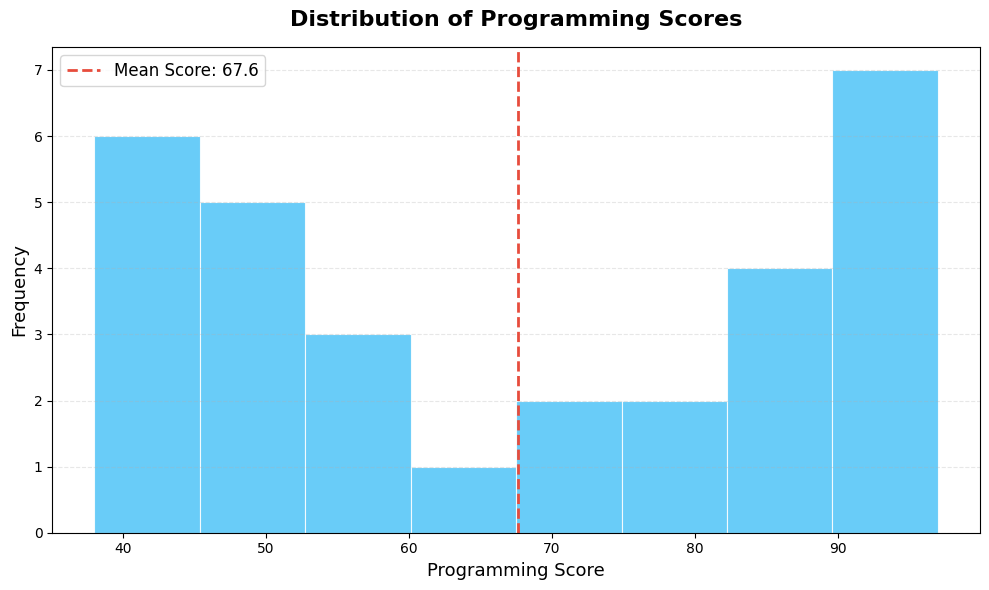

In [ ]:
prog_scores = pd.read_sql_query("SELECT programming_score FROM students", conn)['programming_score'].tolist()

fig, ax = plt.subplots(figsize=(10,6))
n,bins, patches = ax.hist(
    prog_scores,
    bins=8,
    color='#4FC3F7',
    edgecolor='white',
    linewidth=0.8,
    alpha=0.85
)
mean_score = sum(prog_scores)/len(prog_scores)
ax.axvline(
    x=mean_score,
    color='#E74C3C',
    linestyle='--',
    linewidth=2,
    label=f'Mean Score: {mean_score:.1f}'
)

ax.set_title('Distribution of Programming Scores', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Programming Score', fontsize=13)
ax.set_ylabel('Frequency', fontsize=13)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

MINI PROJECT — Student Performance Dashboard

Build a professional Student Performance Dashboard using SQL, Pandas, and Matplotlib.

You are given a SQLite database containing a table named students with the following columns:

name, department, gender, math_score, science_score, english_score, programming_score, attendance_percentage

In [ ]:
avg_math_query = """
    SELECT
        department,
        ROUND(AVG(math_score), 1) AS avg_math_score
    FROM students
    GROUP BY department
    ORDER BY avg_math_score DESC
"""
avg_math_df = pd.read_sql_query(avg_math_query, conn)
print(avg_math_df)

         department  avg_math_score
0  Computer Science            85.6
1        Mechanical            71.0
2       Electronics            71.0
3             Civil            63.4


Write SQL queries using pd.read_sql_query() to answer the following questions: 1.What is the average math score for each department?

Use AVG() Round values to 1 decimal place Sort from highest to lowest average

In [ ]:
query = """
    SELECT
        department,
        COUNT(*) AS num_students
    FROM students
    GROUP BY department
"""
result = pd.read_sql_query(query, conn)
print(result)

         department  num_students
0             Civil             5
1  Computer Science            13
2       Electronics             6
3        Mechanical             6


2.How many students are present in each department?

Use COUNT(*)

Group the results department-wise

In [ ]:
top_students_query = """
    SELECT
        name,
        math_score + science_score + english_score + programming_score AS total_score
    FROM students
    ORDER BY total_score DESC
    LIMIT 8
"""
top_students_df = pd.read_sql_query(top_students_query, conn)
print(top_students_df)

             name  total_score
0      Ananya Das          371
1     Tanvi Mehta          367
2  Akanksha Yadav          365
3      Arjun Nair          356
4     Divya Singh          356
5  Swati Kulkarni          354
6       Amit Bose          336
7      Suresh Rao          334


Who are the Top 8 students based on total marks?
Total Score = math_score + science_score + english_score + programming_score
Display student name and total score
Sort from highest to lowest total
Show only top 8 students

In [ ]:
avg_attendance_query = """
    SELECT
        gender,
        ROUND(AVG(attendance_percentage), 1) AS avg_attendance
    FROM students
    GROUP BY gender
"""
avg_attendance_df = pd.read_sql_query(avg_attendance_query, conn)
print(avg_attendance_df)

   gender  avg_attendance
0  Female            88.5
1    Male            80.5


4.What is the average attendance percentage by gender?
Use AVG()
Round values to 1 decimal place

After extracting the data, create a dashboard using plt.subplots(2, 2) with 4 panels

Create the following charts:

Panel 1:
Create a vertical bar chart showing average math score by department.
- Add value labels
- Add grid lines
- Set y-axis limit to 105

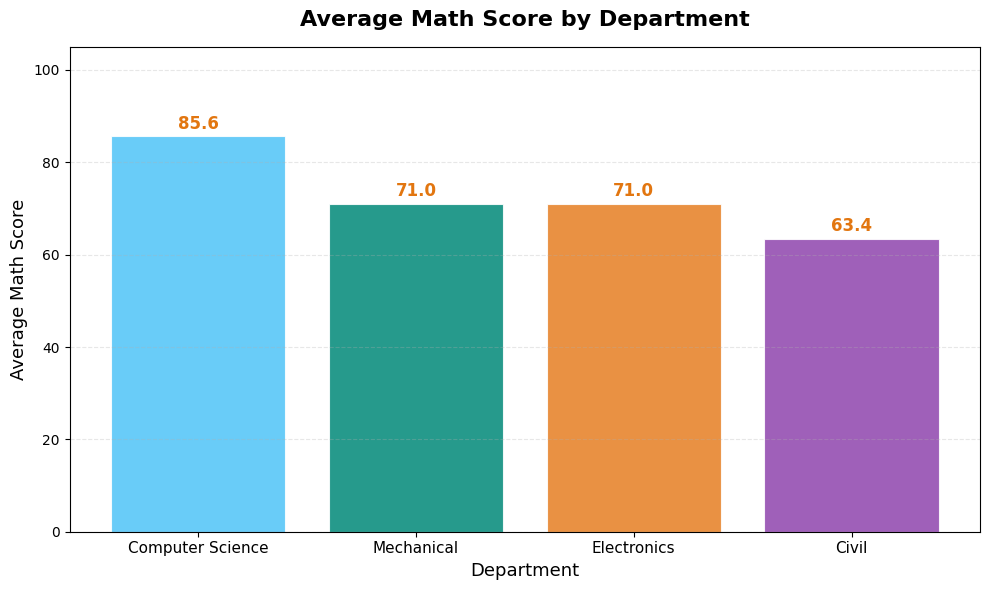

In [ ]:
avg_math_score_query = """
    SELECT
        department,
        ROUND(AVG(math_score), 1) AS avg_math_score
    FROM students
    GROUP BY department
    ORDER BY avg_math_score DESC
"""
avg_math_score_df = pd.read_sql_query(avg_math_score_query, conn)
fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['#4FC3F7', '#008978', '#E67E22', '#8E44AD']
bars = ax.bar(
    avg_math_score_df['department'],
    avg_math_score_df['avg_math_score'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8,
    alpha=0.85
)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f'{height:.1f}',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold',
        color='#E27610'
    )
ax.set_title('Average Math Score by Department', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Department', fontsize=13)
ax.set_ylabel('Average Math Score', fontsize=13)
ax.set_ylim(0, 105)
ax.tick_params(axis='x', labelsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Panel 2: Create a pie chart showing the number of students in each department.

Display percentage labels
Use custom colors
Add white borders

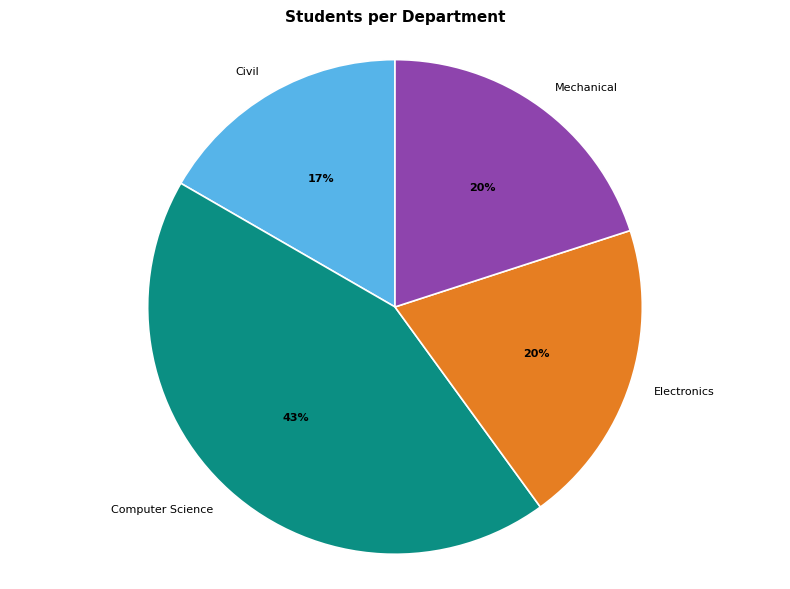

In [ ]:
number_of_students_query = """
    SELECT
        department,
        COUNT(*) AS num_students
    FROM students
    GROUP BY department
"""

# Read data
number_of_students_df = pd.read_sql_query(
    number_of_students_query,
    conn
)

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Colors like image
colors = ['#56B4E9', '#0B8F83', '#E67E22', '#8E44AD']

# Create pie chart
wedges, texts, autotexts = ax.pie(
    number_of_students_df['num_students'],
    labels=number_of_students_df['department'],
    autopct='%1.0f%%',
    startangle=90,
    colors=colors,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 1.2
    },
    textprops={
        'fontsize': 8
    }
)

# Percentage text style
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(8)
    autotext.set_fontweight('bold')

# Title
ax.set_title(
    'Students per Department',
    fontsize=11,
    fontweight='bold',
    pad=10
)

# Make circle perfect
ax.axis('equal')

# Clean layout
plt.tight_layout()

# Show chart
plt.show()

Panel 3: Create a horizontal bar chart showing the Top 8 students based on total score.

Display total scores inside the bars
Place the highest scorer at the top
Add x-axis grid lines

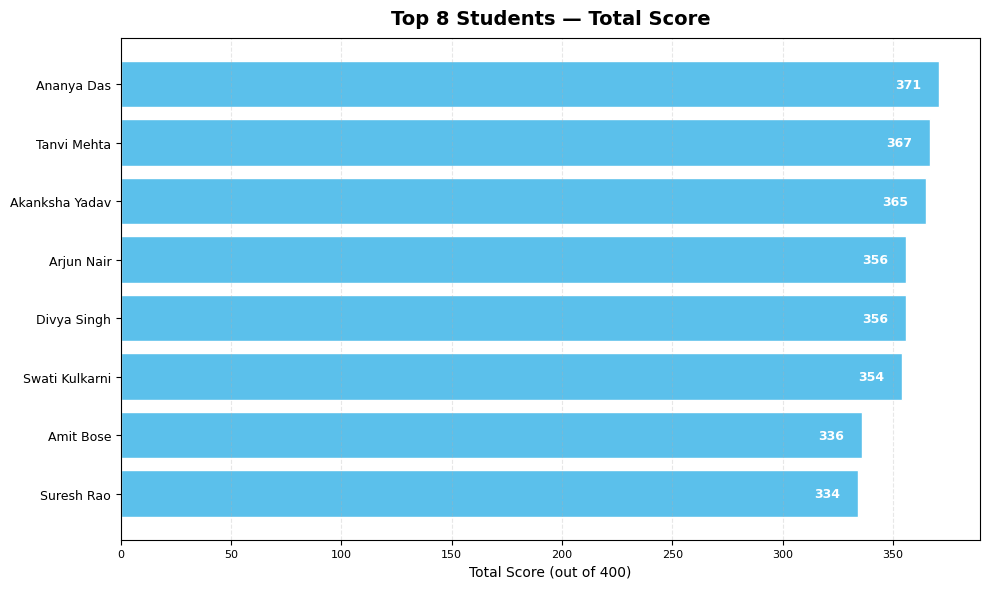

In [ ]:
total_score_query = """
    SELECT
        name,
        math_score + science_score + english_score + programming_score AS total_score
    FROM students
    ORDER BY total_score DESC
    LIMIT 8
"""

# Read data
total_score_df = pd.read_sql_query(total_score_query, conn)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal bar chart
bars = ax.barh(
    total_score_df['name'],
    total_score_df['total_score'],
    color='#5BC0EB',        # Light blue like image
    edgecolor='white',
    linewidth=1,
    height=0.8
)

# Add score labels inside bars
for bar in bars:
    width = bar.get_width()

    ax.text(
        width - 8,                          # Position inside bar
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        ha='right',
        va='center',
        fontsize=9,
        fontweight='bold',
        color='white'
    )

# Title and labels
ax.set_title(
    'Top 8 Students — Total Score',
    fontsize=14,
    fontweight='bold',
    pad=10
)

ax.set_xlabel('Total Score (out of 400)', fontsize=10)
ax.set_ylabel('')

# Grid style
ax.grid(axis='x', linestyle='--', alpha=0.3)

# Highest score at top
ax.invert_yaxis()

# Tick sizes
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=9)

# Clean layout
plt.tight_layout()

# Show graph
plt.show()

Panel 4: Create a bar chart showing average attendance percentage by gender.

Use different colors
Display percentage labels
Set y-axis limit to 105
Add grid lines

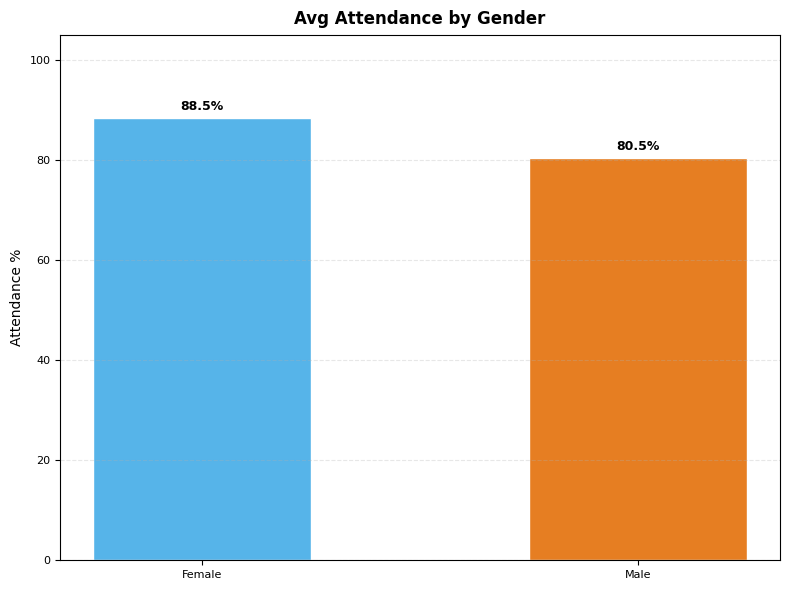

In [ ]:
avg_attendance_percentage_query = """
    SELECT
        gender,
        ROUND(AVG(attendance_percentage), 1) AS avg_attendance
    FROM students
    GROUP BY gender
"""

# Read data
avg_attendance_percentage_df = pd.read_sql_query(
    avg_attendance_percentage_query,
    conn
)

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Bar colors like image
bar_colors = ['#56B4E9', '#E67E22']

# Create bar chart
bars = ax.bar(
    avg_attendance_percentage_df['gender'],
    avg_attendance_percentage_df['avg_attendance'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1,
    width=0.5
)

# Add percentage labels on top
for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

# Title
ax.set_title(
    'Avg Attendance by Gender',
    fontsize=12,
    fontweight='bold',
    pad=8
)

# Y-axis label
ax.set_ylabel('Attendance %')

# Set limits
ax.set_ylim(0, 105)

# Grid style
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Tick sizes
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)

# Clean layout
plt.tight_layout()

# Show graph
plt.show()

Add a professional dashboard title, proper spacing using plt.tight_layout(), and make the dashboard visually attractive.

Save the final dashboard as:

student_dashboard.png

Use:
- dpi=150
- bbox_inches='tight'

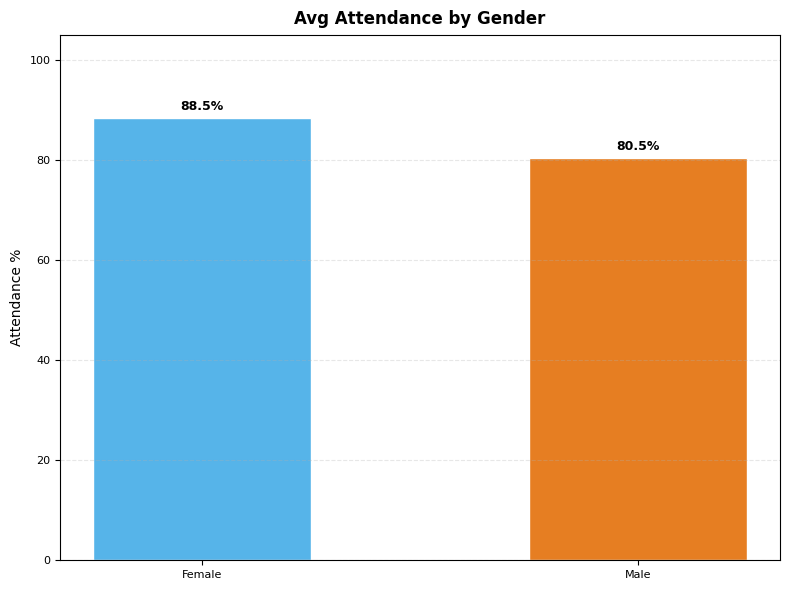

In [ ]:
avg_attendance_percentage_query = """
    SELECT
        gender,
        ROUND(AVG(attendance_percentage), 1) AS avg_attendance
    FROM students
    GROUP BY gender
"""

# Read data
avg_attendance_percentage_df = pd.read_sql_query(
    avg_attendance_percentage_query,
    conn
)

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Bar colors like image
bar_colors = ['#56B4E9', '#E67E22']

# Create bar chart
bars = ax.bar(
    avg_attendance_percentage_df['gender'],
    avg_attendance_percentage_df['avg_attendance'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1,
    width=0.5
)

# Add percentage labels on top
for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

# Title
ax.set_title(
    'Avg Attendance by Gender',
    fontsize=12,
    fontweight='bold',
    pad=8
)

# Y-axis label
ax.set_ylabel('Attendance %')

# Set limits
ax.set_ylim(0, 105)

# Grid style
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Tick sizes
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)

# Clean layout
plt.tight_layout()

# Show graph
plt.show()

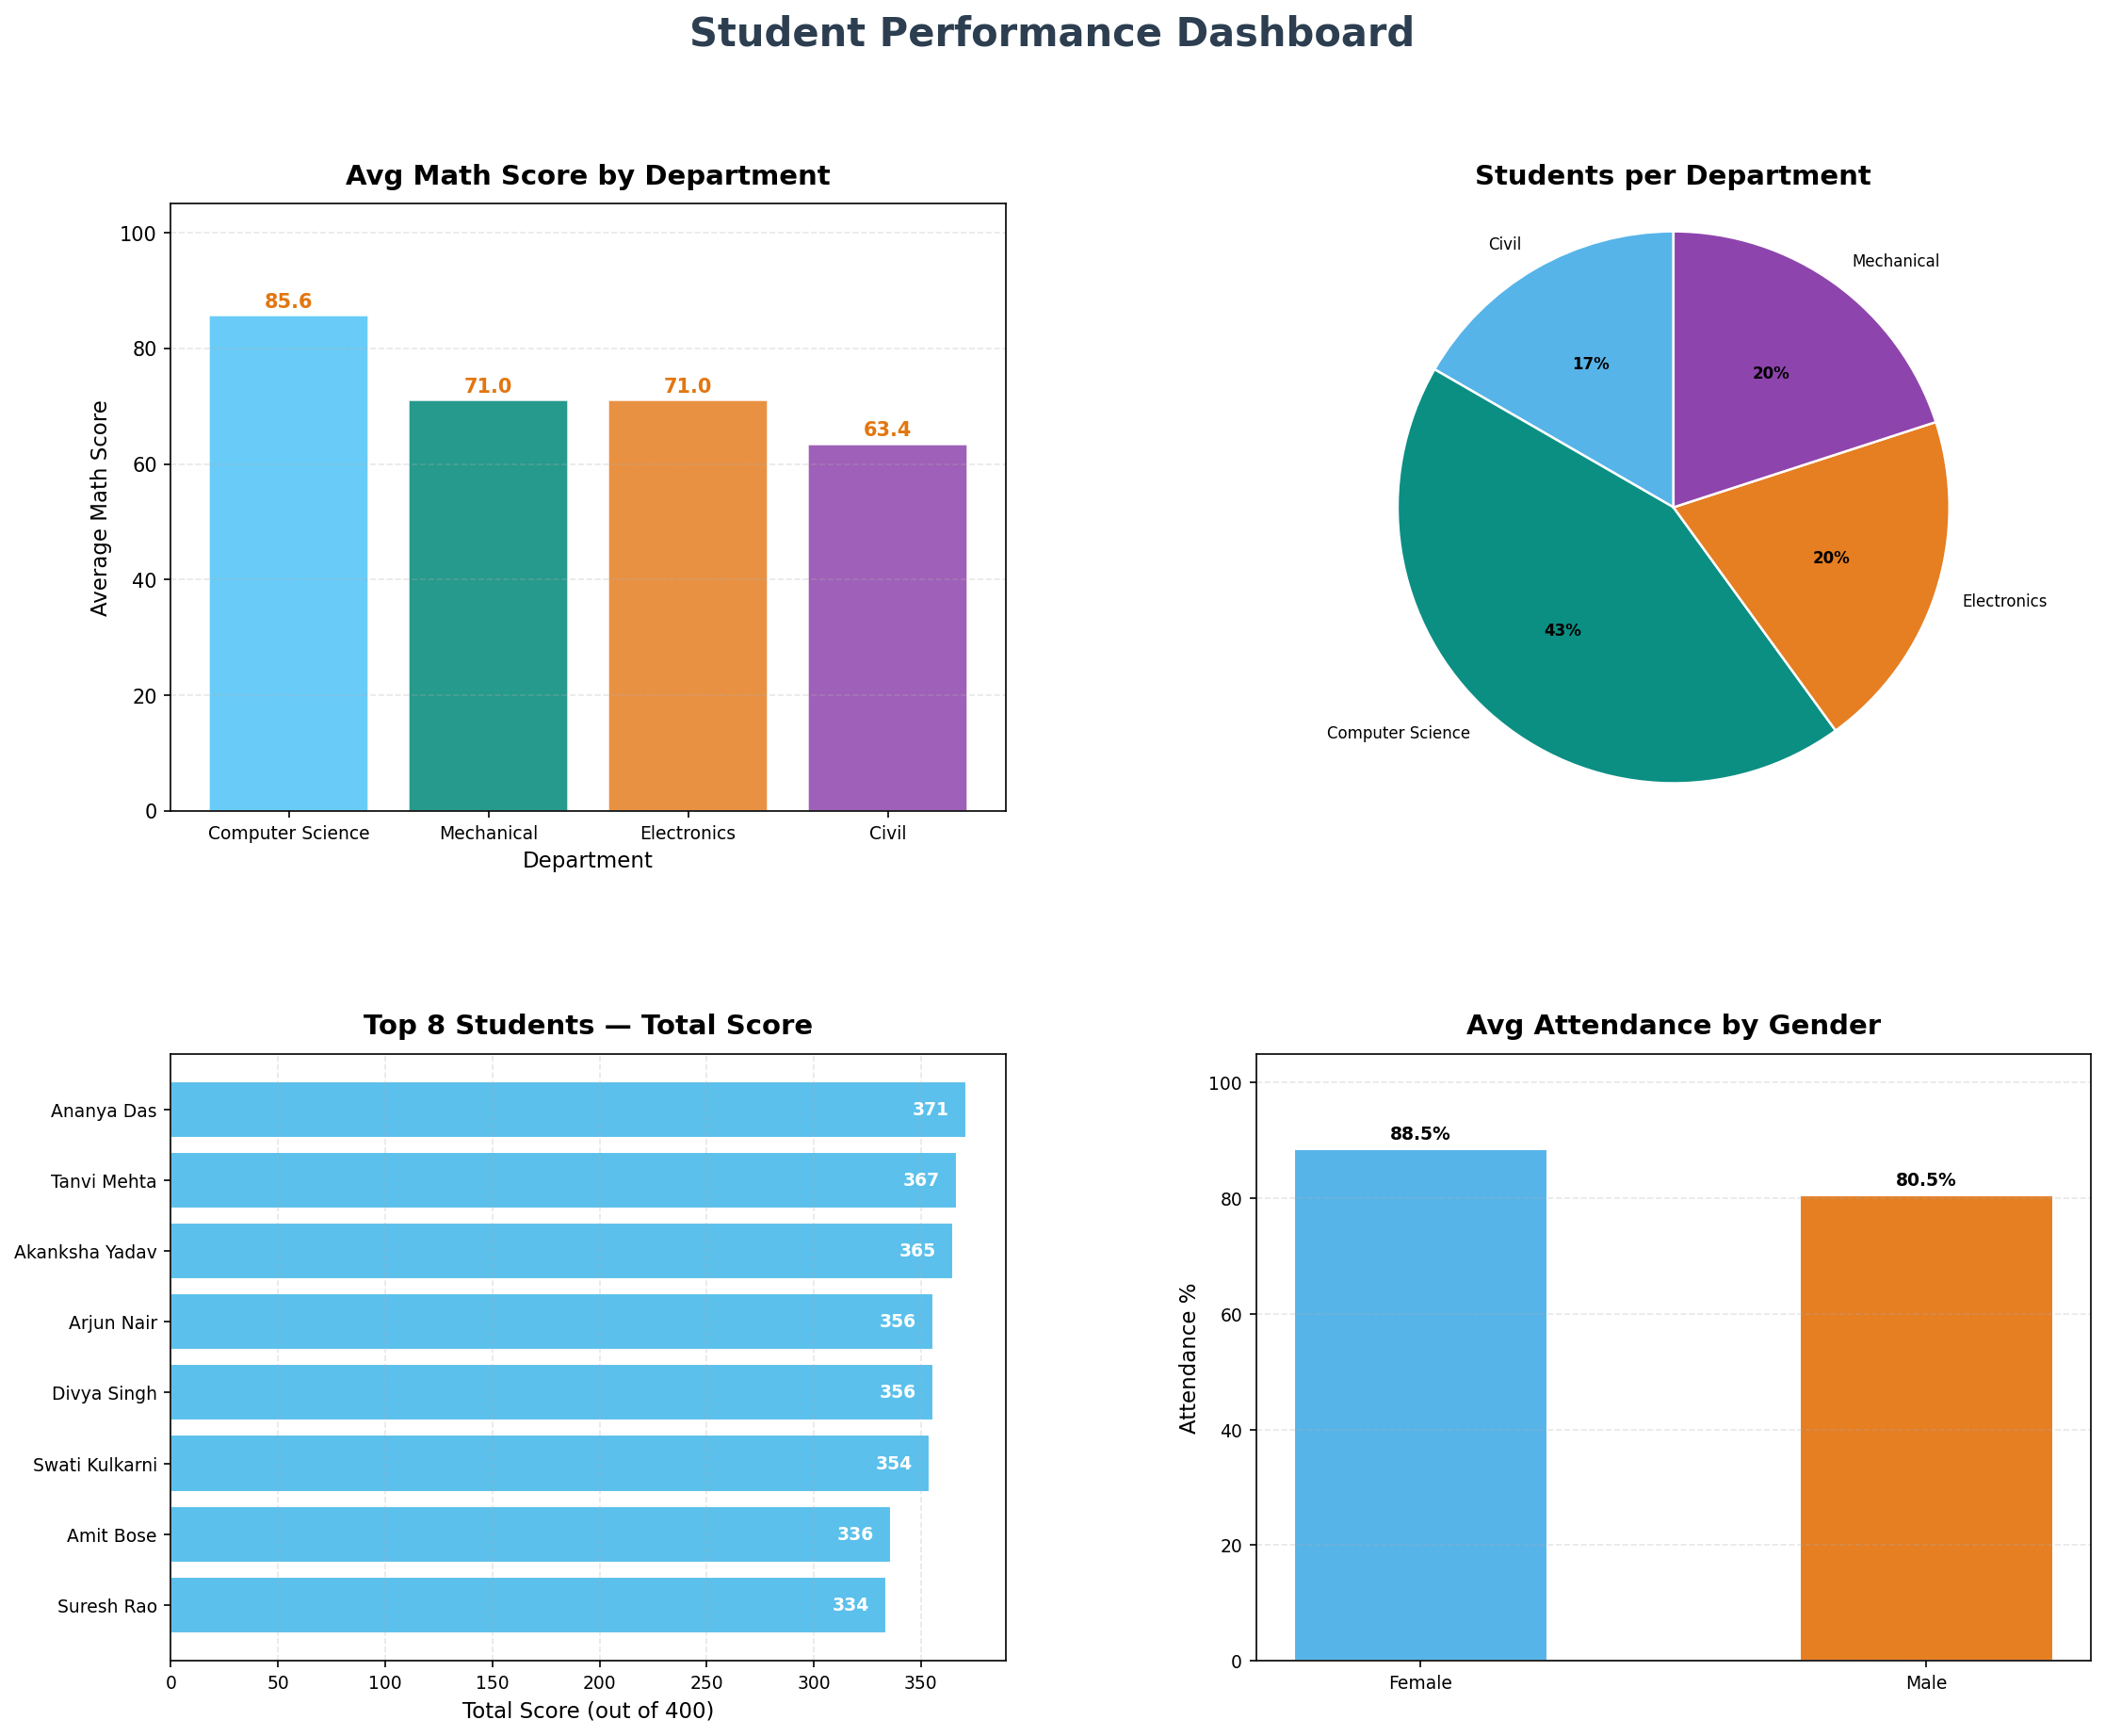

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12), dpi=150) # Create 2x2 subplots for the dashboard

# --- Panel 1: Average Math Score by Department (from t_Kq8UYCP2QB) ---
avg_math_score_query = """
    SELECT
        department,
        ROUND(AVG(math_score), 1) AS avg_math_score
    FROM students
    GROUP BY department
    ORDER BY avg_math_score DESC
"""
avg_math_score_df = pd.read_sql_query(avg_math_score_query, conn)
ax = axes[0, 0] # Assign to top-left subplot
bar_colors = ['#4FC3F7', '#008978', '#E67E22', '#8E44AD']
bars = ax.bar(
    avg_math_score_df['department'],
    avg_math_score_df['avg_math_score'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8,
    alpha=0.85
)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f'{height:.1f}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold',
        color='#E27610'
    )
ax.set_title('Avg Math Score by Department', fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('Department', fontsize=11)
ax.set_ylabel('Average Math Score', fontsize=11)
ax.set_ylim(0, 105)
ax.tick_params(axis='x', labelsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# --- Panel 2: Students per Department Pie Chart (from cCLom8iOQCh_) ---
number_of_students_query = """
    SELECT
        department,
        COUNT(*) AS num_students
    FROM students
    GROUP BY department
"""
number_of_students_df = pd.read_sql_query(number_of_students_query, conn)
ax = axes[0, 1] # Assign to top-right subplot
colors = ['#56B4E9', '#0B8F83', '#E67E22', '#8E44AD']
wedges, texts, autotexts = ax.pie(
    number_of_students_df['num_students'],
    labels=number_of_students_df['department'],
    autopct='%1.0f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    textprops={'fontsize': 8}
)
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(8)
    autotext.set_fontweight('bold')
ax.set_title('Students per Department', fontsize=14, fontweight='bold', pad=10)
ax.axis('equal')

# --- Panel 3: Top 8 Students by Total Score (from W259Z9ygQGDc) ---
total_score_query = """
    SELECT
        name,
        math_score + science_score + english_score + programming_score AS total_score
    FROM students
    ORDER BY total_score DESC
    LIMIT 8
"""
total_score_df = pd.read_sql_query(total_score_query, conn)
ax = axes[1, 0] # Assign to bottom-left subplot
bars = ax.barh(
    total_score_df['name'],
    total_score_df['total_score'],
    color='#5BC0EB',
    edgecolor='white',
    linewidth=1,
    height=0.8
)
for bar in bars:
    width = bar.get_width()
    ax.text(
        width - 8,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        ha='right', va='center',
        fontsize=9, fontweight='bold',
        color='white'
    )
ax.set_title('Top 8 Students — Total Score', fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('Total Score (out of 400)', fontsize=11)
ax.set_ylabel('')
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.invert_yaxis()
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)

# --- Panel 4: Average Attendance Percentage by Gender (from J4uGKam8QJkI) ---
avg_attendance_percentage_query = """
    SELECT
        gender,
        ROUND(AVG(attendance_percentage), 1) AS avg_attendance
    FROM students
    GROUP BY gender
"""
avg_attendance_percentage_df = pd.read_sql_query(avg_attendance_percentage_query, conn)
ax = axes[1, 1] # Assign to bottom-right subplot
bar_colors = ['#56B4E9', '#E67E22']
bars = ax.bar(
    avg_attendance_percentage_df['gender'],
    avg_attendance_percentage_df['avg_attendance'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1,
    width=0.5
)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold',
        color='black'
    )
ax.set_title('Avg Attendance by Gender', fontsize=14, fontweight='bold', pad=10)
ax.set_ylabel('Attendance %', fontsize=11)
ax.set_ylim(0, 105)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)

# --- Dashboard Customization ---
fig.suptitle(
    'Student Performance Dashboard',
    fontsize=20,
    fontweight='bold',
    color='#2C3E50',
    y=1.02 # Adjust title position to be above subplots
)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make space for suptitle
fig.subplots_adjust(wspace=0.3, hspace=0.4) # Fine-tune spacing between subplots

# Save the dashboard
plt.savefig('student_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()